In [9]:
import os

train_dir = "/Users/shreetu/Documents/more of AI/W5/FruitinAmazon/train"

class_names = sorted(os.listdir(train_dir))

if not class_names:
    print("No class directories found in traning folder")
else:
    print(f"Found {len(class_names)} classes: {class_names}")


test_dir = "/Users/shreetu/Documents/more of AI/W5/FruitinAmazon/test"

test_class_names = sorted(os.listdir(test_dir))

if not test_class_names:
    print("No class directories found in traning folder")
else:
    print(f"Found {len(test_class_names)} classes: {test_class_names}")



Found 7 classes: ['.DS_Store', 'acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Found 7 classes: ['.DS_Store', 'acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


In [10]:
from PIL import Image, UnidentifiedImageError

corrupted_images = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = os.listdir(class_path) # returns array of images like ['download (3).jpeg', 'download (6).jpeg']
        for img_name in images:
            img_path = os.path.join(class_path, img_name)
            try:
                with Image.open(img_path) as img:
                    img.verify()
            except (IOError, UnidentifiedImageError):
                corrupted_images.append(img_path)
        
# Print results
if corrupted_images:
    print("\nCorrupted Images Found in traning dataset:")
    for img in corrupted_images:
        print(img)
else:
    print("\nNo corrupted images found in traning dataset.")

test_corrupted_images = []

for class_name in test_class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        test_images = os.listdir(class_path) # returns array of images like ['download (3).jpeg', 'download (6).jpeg']
        for img_name in test_images:
            img_path = os.path.join(class_path, img_name)
            try:
                with Image.open(img_path) as img:
                    img.verify()
            except (IOError, UnidentifiedImageError):
                corrupted_images.append(img_path)
        
# Print results
if corrupted_images:
    print("\nCorrupted Images Found in testing dataset:")
    for img in test_corrupted_images:
        print(img)
else:
    print("\nNo corrupted images found in testing dataset.")


No corrupted images found in traning dataset.

No corrupted images found in testing dataset.


In [5]:
class_counts = {}
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        class_counts[class_name] = len(images) # Count images in each class
# Print Class Balance
print("\nClass Distribution:")
print("=" * 45)
print(f"{'Class Name':<25}{'Valid Image Count':>15}")
print("=" * 45)
for class_name, count in class_counts.items():
    print(f"{class_name:<25}{count:>15}")
print("=" * 45)


Class Distribution:
Class Name               Valid Image Count
acai                                  15
cupuacu                               15
graviola                              15
guarana                               15
pupunha                               15
tucuma                                15


In [11]:
test_class_counts = {}
for class_name in test_class_names:
    class_path = os.path.join(test_dir, class_name)
    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        test_class_counts[class_name] = len(images) # Count images in each class
# Print Class Balance
print("\nClass Distribution:")
print("=" * 45)
print(f"{'Class Name':<25}{'Valid Image Count':>15}")
print("=" * 45)
for class_name, count in test_class_counts.items():
    print(f"{class_name:<25}{count:>15}")
print("=" * 45)


Class Distribution:
Class Name               Valid Image Count
acai                                   5
cupuacu                                5
graviola                               5
guarana                                5
pupunha                                5
tucuma                                 5


In [14]:
test_class_counts = {}
for class_name in test_class_names:
    class_path = os.path.join(test_dir, class_name)
    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        test_class_counts[class_name] = len(images) # Count images in each class
# Print Class Balance
print("\nClass Distribution:")
print("=" * 45)
print(f"{'Class Name':<25}{'Valid Image Count':>15}")
print("=" * 45)
for class_name, count in test_class_counts.items():
    print(f"{class_name:<25}{count:>15}")
print("=" * 45)


Class Distribution:
Class Name               Valid Image Count
acai                                   5
cupuacu                                5
graviola                               5
guarana                                5
pupunha                                5
tucuma                                 5


In [15]:
import random
selected_images = [] # Store image paths
selected_labels = [] # Store corresponding class names
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if images: # Ensure the class folder is not empty
            selected_img = os.path.join(class_path, random.choice(images))
            selected_images.append(selected_img)
            selected_labels.append(class_name)

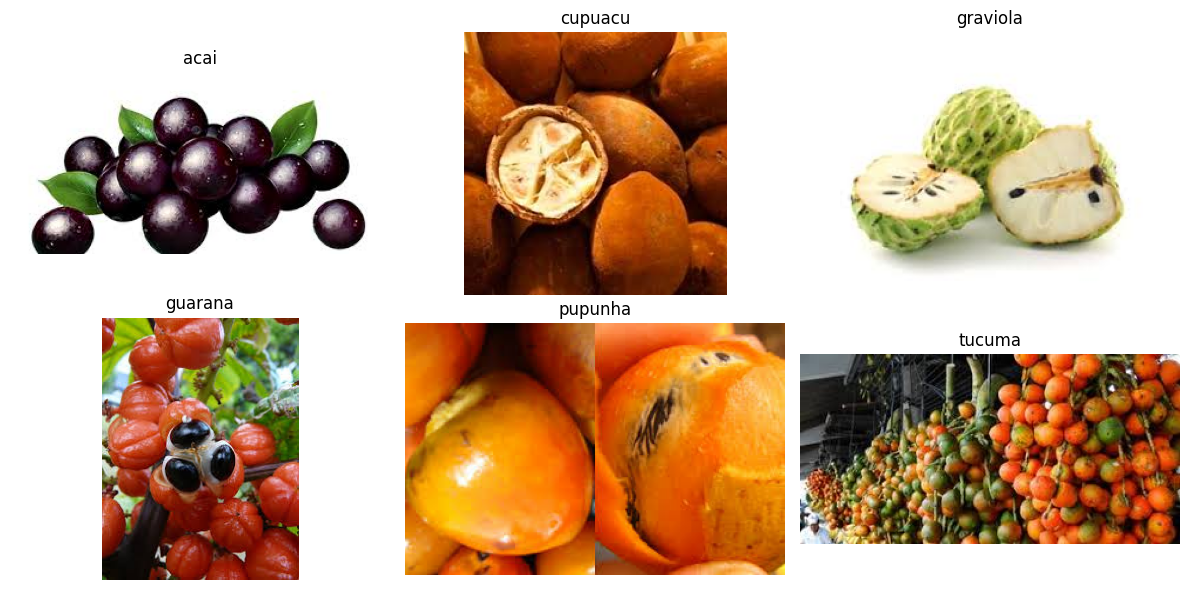

In [16]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
# Determine grid size
num_classes = len(selected_images)
cols = (num_classes + 1) // 2 # Determine columns
rows = 2 # Fixed rows for layout
fig, axes = plt.subplots(rows, cols, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    if i < num_classes:
        img = mpimg.imread(selected_images[i])
        ax.imshow(img)
        ax.set_title(selected_labels[i])
        ax.axis("off")
    else:
        ax.axis("off") # Hide empty subplots
plt.tight_layout()
plt.show()

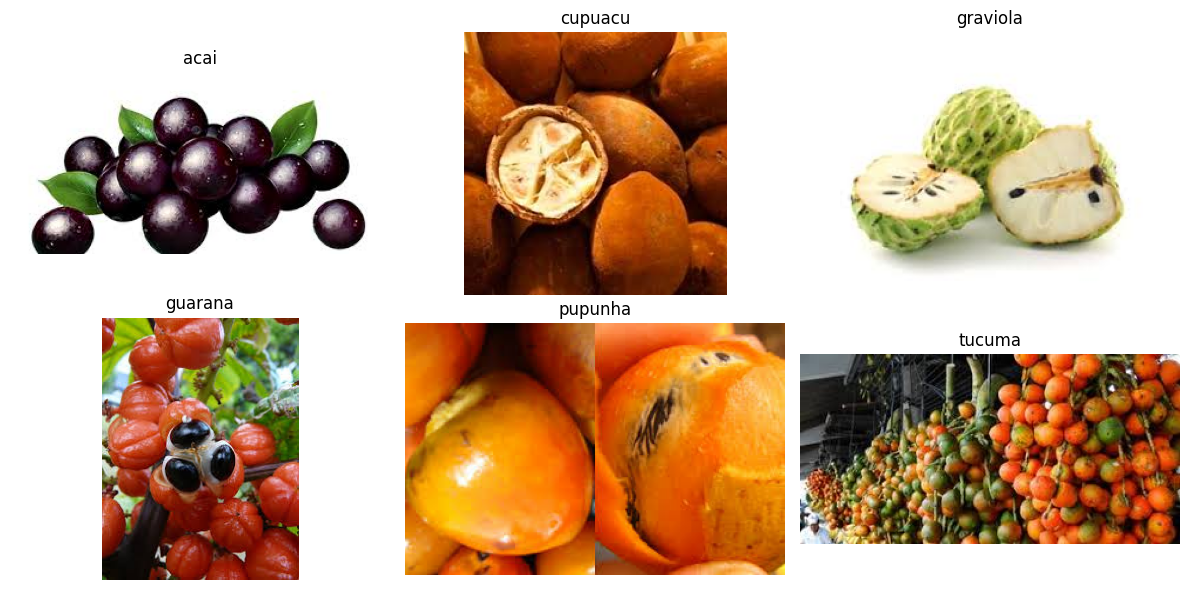

In [17]:

num_classes = len(selected_images)
cols = (num_classes + 1) // 2 # Determine columns
rows = 2 # Fixed rows for layout
fig, axes = plt.subplots(rows, cols, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    if i < num_classes:
        img = mpimg.imread(selected_images[i])
        ax.imshow(img)
        ax.set_title(selected_labels[i])
        ax.axis("off")
    else:
        ax.axis("off") # Hide empty subplots
plt.tight_layout()
plt.show()

In [19]:
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow import keras
image_size = (128, 128)
batch_size = 32
train_ds, val_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="both",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Using 18 files for validation.


In [20]:
test_ds = keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(128, 128),  
    batch_size=32,
    shuffle=False  
)

Found 30 files belonging to 6 classes.


In [21]:
for images, labels in train_ds.take(1): # Take one batch
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

Images shape: (32, 128, 128, 3)
Labels shape: (32,)


In [22]:
for images, labels in test_ds.take(1): # Take one batch
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

Images shape: (30, 128, 128, 3)
Labels shape: (30,)


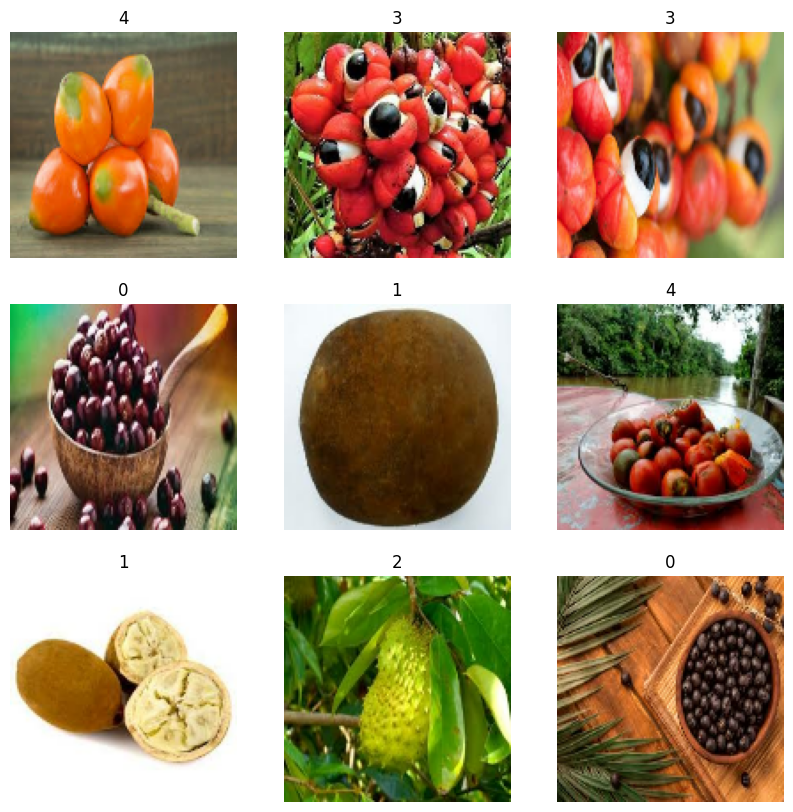

In [23]:
import numpy as np
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1): #Takes one batch of images from the dataset (train_ds):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(images[i]).astype("uint8"))
        plt.title(int(labels[i]))
        plt.axis("off")
plt.show()

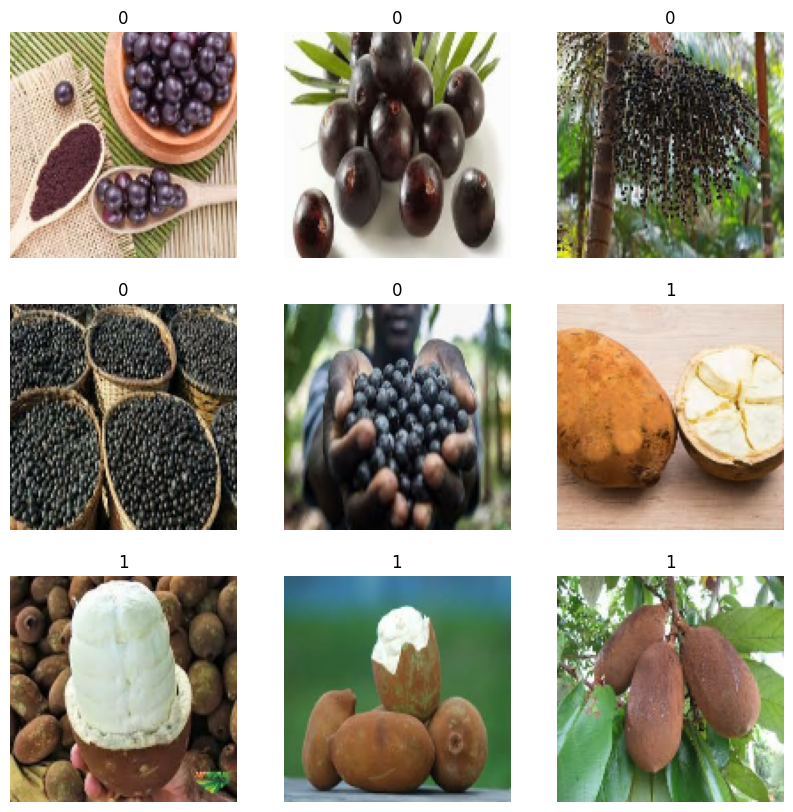

In [24]:
import numpy as np
plt.figure(figsize=(10, 10))
for images, labels in test_ds.take(1): #Takes one batch of images from the dataset (train_ds):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(images[i]).astype("uint8"))
        plt.title(int(labels[i]))
        plt.axis("off")
plt.show()

In [25]:
import tensorflow as tf
from tensorflow.keras import layers

data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2)
]
def data_augmentation(images):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images

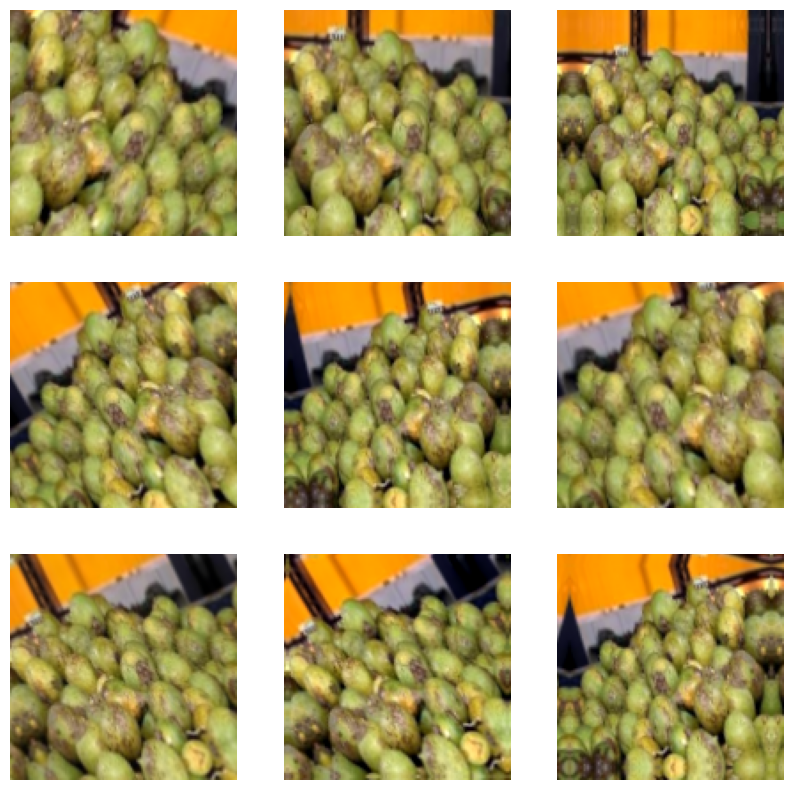

In [26]:
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(augmented_images[0]).astype("uint8"))
        plt.axis("off")

Model architecture created successfully!/n
Model Summary:


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             

 Total params: 8,956,166 (34.17 MB)

 Trainable params: 8,953,286 (34.15 MB)

 Non-trainable params: 2,880 (11.25 KB)

In [36]:
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras import layers

augmentation_model = keras.Sequential([
    layers.Input(shape=(128, 128, 3)),  
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.15),
    layers.RandomTranslation(0.1, 0.1),
], name="augmentation")

model = Sequential([
    augmentation_model,
    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    
    layers.Conv2D(128, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(6, activation='softmax')
])

print("Model architecture created successfully!")
model.summary()

Model architecture created successfully!


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_3 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,288,454 (16.36 MB)

 Trainable params: 4,288,454 (16.36 MB)

 Non-trainable params: 0 (0.00 B)

In [38]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [39]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)
 
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,
    verbose=1,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    batch_size=32,
    callbacks=[checkpoint, early_stopping],
    verbose=1
)

Epoch 1/25
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.0938 - loss: 1.9415
Epoch 1: val_loss improved from None to 1.85484, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 132ms/step - accuracy: 0.1389 - loss: 2.0603 - val_accuracy: 0.0556 - val_loss: 1.8548
Epoch 2/25
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.2266 - loss: 1.8340
Epoch 2: val_loss improved from 1.85484 to 1.78469, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.1806 - loss: 1.8412 - val_accuracy: 0.1667 - val_loss: 1.7847
Epoch 3/25
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.1748 - loss: 1.7693 
Epoch 3: val_loss did not improve from 1.78469
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.1806 - loss: 1.7711 - val_accuracy: 0.1111 - val_loss: 1.8245
Epoch 4/25
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.1797 - loss: 1.7485
Epoch 4: val_loss did not improve from 1.78469
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.2222 - loss: 1.7480 - val_accuracy: 0.1667 - val_loss: 1.8503
Epoch 5/25
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.3203 - loss: 1.7076
Epoch 5: val_loss did not improve from 1.78469
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.3333 - loss: 1.6850 - val_accuracy: 0.2778 - val_loss: 1.7976
Epoch 6/25
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.4375 - loss: 1.5755
Epoch 6: val_los


Epoch 7: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.4167 - loss: 1.4140 - val_accuracy: 0.1667 - val_loss: 1.5908
Epoch 8/25
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.5312 - loss: 1.2778
Epoch 8: val_loss did not improve from 1.59082
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.4583 - loss: 1.3684 - val_accuracy: 0.2778 - val_loss: 1.6650
Epoch 9/25
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.5703 - loss: 1.2656
Epoch 9: val_loss improved from 1.59082 to 1.53801, saving model to best_model.h5



Epoch 9: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.4722 - loss: 1.3666 - val_accuracy: 0.2222 - val_loss: 1.5380
Epoch 10/25
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.5547 - loss: 1.2688
Epoch 10: val_loss improved from 1.53801 to 1.44536, saving model to best_model.h5



Epoch 10: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.5139 - loss: 1.3418 - val_accuracy: 0.4444 - val_loss: 1.4454
Epoch 11/25
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.5859 - loss: 1.2745
Epoch 11: val_loss did not improve from 1.44536
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.5417 - loss: 1.3017 - val_accuracy: 0.4444 - val_loss: 1.4792
Epoch 12/25
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.5078 - loss: 1.2543
Epoch 12: val_loss did not improve from 1.44536
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.5417 - loss: 1.1883 - val_accuracy: 0.3333 - val_loss: 1.6158
Epoch 13/25
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.5234 - loss: 1.2196
Epoch 13: val_loss improved from 1.44536 to 1.35095, saving model to best_model.h5



Epoch 13: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.5139 - loss: 1.2182 - val_accuracy: 0.5000 - val_loss: 1.3510
Epoch 14/25
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.5938 - loss: 0.9829
Epoch 14: val_loss did not improve from 1.35095
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.5833 - loss: 1.0070 - val_accuracy: 0.3889 - val_loss: 1.5752
Epoch 15/25
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.6172 - loss: 0.9541
Epoch 15: val_loss did not improve from 1.35095
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.6111 - loss: 0.9957 - val_accuracy: 0.4444 - val_loss: 1.7556
Epoch 16/25
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.7109 - loss: 0.7779
Epoch 16: val_loss improved from 1.35095 to 1.33999, saving model to best_model.h5



Epoch 16: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.7083 - loss: 0.8285 - val_accuracy: 0.6111 - val_loss: 1.3400
Epoch 17/25
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.6641 - loss: 0.8467
Epoch 17: val_loss did not improve from 1.33999
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.6389 - loss: 0.8870 - val_accuracy: 0.6111 - val_loss: 1.4120
Epoch 18/25
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.7578 - loss: 0.8091
Epoch 18: val_loss did not improve from 1.33999
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.6944 - loss: 0.8996 - val_accuracy: 0.3333 - val_loss: 1.9279
Epoch 19/25
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.6094 - loss: 0.9535
Epoch 19: val_loss did not improve from 1.33999
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.6806 - loss: 0.8631 - val_accuracy: 0.5556 - val_loss: 1.5067
Epoch 20/25
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.7812 - loss: 0.6720
Epoch 20:


Epoch 20: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.7361 - loss: 0.7642 - val_accuracy: 0.5556 - val_loss: 1.1189
Epoch 21/25
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.6641 - loss: 0.9874
Epoch 21: val_loss improved from 1.11890 to 1.07389, saving model to best_model.h5



Epoch 21: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.6250 - loss: 0.9793 - val_accuracy: 0.6111 - val_loss: 1.0739
Epoch 22/25
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.7266 - loss: 0.7538
Epoch 22: val_loss did not improve from 1.07389
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.7083 - loss: 0.8166 - val_accuracy: 0.3889 - val_loss: 2.0448
Epoch 23/25
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.7188 - loss: 0.7870
Epoch 23: val_loss did not improve from 1.07389
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.7222 - loss: 0.7905 - val_accuracy: 0.6111 - val_loss: 1.2673
Epoch 24/25
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.8125 - loss: 0.6873
Epoch 24: val_loss did not improve from 1.07389
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.8056 - loss: 0.6748 - val_accuracy: 0.6111 - val_loss: 1.0918
Epoch 25/25
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.7656 - loss: 0.7525
Epoch 25:

In [40]:
test_loss, test_accuracy = model.evaluate(test_ds, verbose=1)
 
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.6667 - loss: 0.7528
Test Loss: 0.7528
Test Accuracy: 0.6667 (66.67%)


In [41]:
model.save('trained_fruit_model.keras')
loaded_model = keras.models.load_model('trained_fruit_model.keras')
print(" Loaded successfully!")

 Loaded successfully!


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
from tensorflow.keras.applications import VGG16
# Load the VGG16 model pre-trained on ImageNet, without the top classification layer
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

 9748480/58889256 ━━━━━━━━━━━━━━━━━━━━ 1:55 2us/step